> **在线运行说明。** 下一格安装 `coptpy`。内置的免费许可有规模上限，但足够跑通本案例。然后执行「运行所有」。


In [ ]:
# COPT Python API and this case's dependencies
!pip install -q coptpy matplotlib numpy pandas scikit-learn seaborn statsmodels


In [ ]:
# 中文字体：运行环境通常没有 CJK 字体，注册随仓库分发的思源黑体子集
import os, urllib.request, matplotlib, matplotlib.font_manager as fm
FONT = 'NotoSansCJKsc-Regular-subset.otf'
CAND = [FONT, os.path.join('..', 'assets', FONT), os.path.join('..', '..', 'assets', FONT),
        os.path.join('assets', FONT)]
URLS = [
    'https://raw.githubusercontent.com/tztgracious/copt-colab-cases/main/assets/' + FONT,
    'https://gitee.com/tztgracious/copt-colab-cases/raw/main/assets/' + FONT,
]
path = next((p for p in CAND if os.path.exists(p)), None)
if path is None:
    for u in URLS:
        try:
            urllib.request.urlretrieve(u, FONT); path = FONT; break
        except Exception:
            continue
if path:
    fm.fontManager.addfont(path)
    matplotlib.rcParams['font.sans-serif'] = [fm.FontProperties(fname=path).get_name()]
    matplotlib.rcParams['axes.unicode_minus'] = False
    print('中文字体已就绪:', matplotlib.rcParams['font.sans-serif'][0])
else:
    print('未能加载中文字体，图表中的中文可能显示为方块')

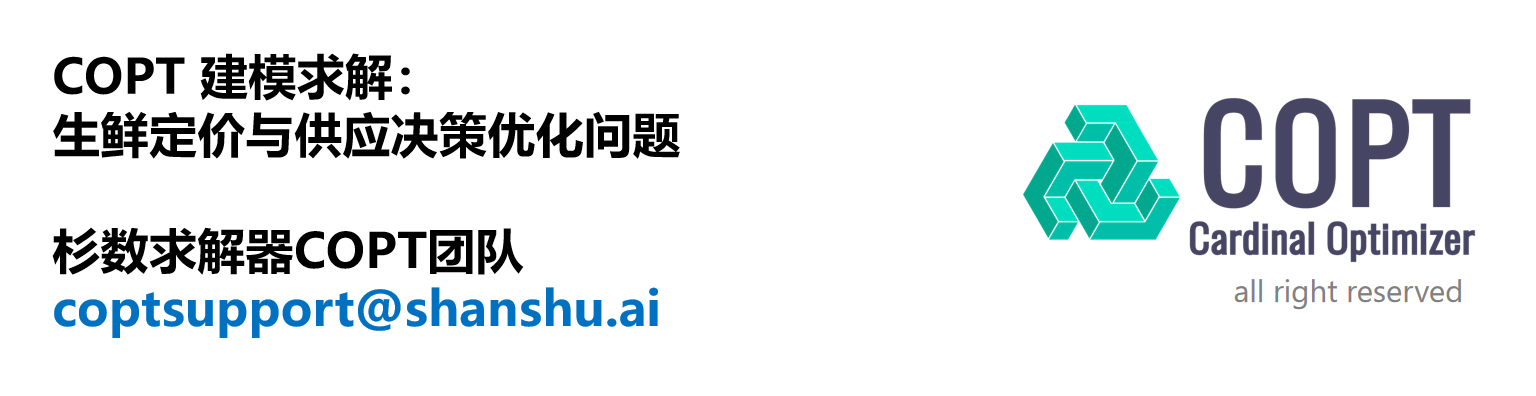

# 生鲜定价与供应决策优化问题

## 使用COPT建模求解生鲜定价与供应决策优化问题的步骤

### 准备部分：数据集生成与预处理

### 第一部分：描述性分析

1. **选取全国整体数据分析**
    - **月度销量变化**
    - **季节性分析**

### 第二部分：预测性分析

1. **数据集拆分** ：80% 的训练集和 20% 的测试集

2. **构建 OLS 回归模型**

3. **输出回归结果**

4. **计算 R² 指标**

### 第三部分：决策性分析

1. **导入COPT-Python接口库** `coptpy`

2. **创建COPT求解环境与模型**

3. **构建模型：依次添加三要素**
    - **决策变量**：
        -   $\text{price}_r$: 地区 $r$ 的销售价格。这是一个连续变量，代表在给定范围内为该地区设定的商品单价。
        -   $\text{num}_r$: 地区 $r$ 的商品分配量。这是一个连续变量，表示从总库存中分配给地区 $r$ 的商品数量。
        -   $\text{supply}_r$: 地区 $r$ 的实际销售量。这是一个辅助变量，表示在给定价格和分配量下，地区 $r$ 实际能够售出的商品数量。
        -   $\text{waste}_r$: 地区 $r$ 的商品浪费数量。这是一个辅助变量，表示分配到地区 $r$ 但未能售出而造成的浪费量。
        -   $\text{c}_{\text{waste}}$: 每件浪费商品的损耗成本
        -   $\text{c}^{r}_{\text{transport}}$: 分配至地区 $r$ 的运输成本
    - **目标函数**：最大化所有地区的总净收益
    - **约束条件**：
        1. 供应量约束
        2. 销售数量约束
        3. 浪费数量约束

4. **求解**

5. 查看、分析**结果**


## 加载依赖包与数据集

接下来，我们将加载一些用于数据分析与可视化的 Python 包。

In [1]:
import pandas as pd
import warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
from sklearn import tree 
import seaborn as sns
import sklearn 
import numpy as np  
import coptpy as cp
from coptpy import COPT

In [2]:
# 设定随机种子
rng = np.random.default_rng(42)

# 中国地区
regions = ["EastChina", "NorthChina", "SouthChina", "Southwest", "CentralChina"]

# 产品类型
types = ["Domestic", "Imported"]

# 2020–2025 每周日期（按周生成）
dates = pd.date_range("2020-01-05", "2025-12-28", freq="7D")

rows = []

for d in dates:
    month = d.month

    # ---- 季节性因子 ----
    if month in [7, 8]:
        season_factor = 1.70
    elif month in [4, 5, 6, 9, 10]:
        season_factor = 1.20
    else:
        season_factor = 0.60


    for r in regions:

        # ---- 地区基准需求差异 ----
        if r in ["EastChina", "SouthChina"]:
            region_demand_base = 520000
            region_price_shift = 0.28
        elif r == "CentralChina":
            region_demand_base = 450000
            region_price_shift = 0.18
        else:  # NorthChina, Southwest
            region_demand_base = 380000
            region_price_shift = 0.10

        for t in types:

            # ---- 类型差异（国产 vs 进口）----
            if t == "Imported":
                type_price_base = 5.2
                type_demand_factor = 0.85
            else:
                type_price_base = 4.3
                type_demand_factor = 1.0

            # ---- 随机价格（限制在 2–8 元）----
            price = (
                type_price_base
                + region_price_shift
                + rng.normal(loc=0.0, scale=0.30)
            )
            price = max(2.0, min(price, 8.0))

            # ---- 销量模型（随价格下降而减少）----
            demand_base = region_demand_base * season_factor * type_demand_factor

            units = (
                demand_base * (1 - 0.25 * (price - 4.8)) 
                + rng.normal(loc=0, scale=45000)
            )
            

            units = max(60000, units)  # 防止过低

            rows.append({
                "region": r,
                "date": d,
                "type": t,
                "price": round(float(price), 4),
                "units_sold": float(units),
            })

df = pd.DataFrame(rows)

# 展示前十行查看数据结构
df.head(10)

,region,date,type,price,units_sold
0,EastChina,2020-01-05,Domestic,4.6714,275230.335553
1,EastChina,2020-01-05,Imported,5.7051,247514.937953
2,NorthChina,2020-01-05,Domestic,3.8147,225564.623917
3,NorthChina,2020-01-05,Imported,5.3384,153485.923085
4,SouthChina,2020-01-05,Domestic,4.5750,291166.170345
5,SouthChina,2020-01-05,Imported,5.7438,237625.411374
6,Southwest,2020-01-05,Domestic,4.4198,300396.729385
7,Southwest,2020-01-05,Imported,5.4403,124111.590881
8,CentralChina,2020-01-05,Domestic,4.5906,240983.079585
9,CentralChina,2020-01-05,Imported,5.6435,178855.508194


## 数据预处理
首先，在原始的 DataFrame 基础上，将新增两个特征列：年份（year）和季节性（seasonality）。其次，考虑到数据覆盖 **2020–2025 年**，需要将它们按照时间顺序映射为整数索引从而便于处理。

此外，我们根据日常生鲜商品的消费特点，定义 **6 月至 8 月为旺季（peak season）**，其余月份视为平季。旺季通常对应需求上升、供应波动加大等现象，非常适合作为回归模型中的一个季节性因子。

In [4]:
df["year"] = pd.to_datetime(df["date"]).dt.year
df["year_index"] = df["year"] - df["year"].min()

df["month"] = pd.to_datetime(df["date"]).dt.month
df["peak"] = df["month"].isin([6,7,8]).astype(int)
df.head(10) 

,region,date,type,price,units_sold,year,year_index,month,peak
0,EastChina,2020-01-05,Domestic,4.6714,275230.335553,2020,0,1,0
1,EastChina,2020-01-05,Imported,5.7051,247514.937953,2020,0,1,0
2,NorthChina,2020-01-05,Domestic,3.8147,225564.623917,2020,0,1,0
3,NorthChina,2020-01-05,Imported,5.3384,153485.923085,2020,0,1,0
4,SouthChina,2020-01-05,Domestic,4.5750,291166.170345,2020,0,1,0
5,SouthChina,2020-01-05,Imported,5.7438,237625.411374,2020,0,1,0
6,Southwest,2020-01-05,Domestic,4.4198,300396.729385,2020,0,1,0
7,Southwest,2020-01-05,Imported,5.4403,124111.590881,2020,0,1,0
8,CentralChina,2020-01-05,Domestic,4.5906,240983.079585,2020,0,1,0
9,CentralChina,2020-01-05,Imported,5.6435,178855.508194,2020,0,1,0


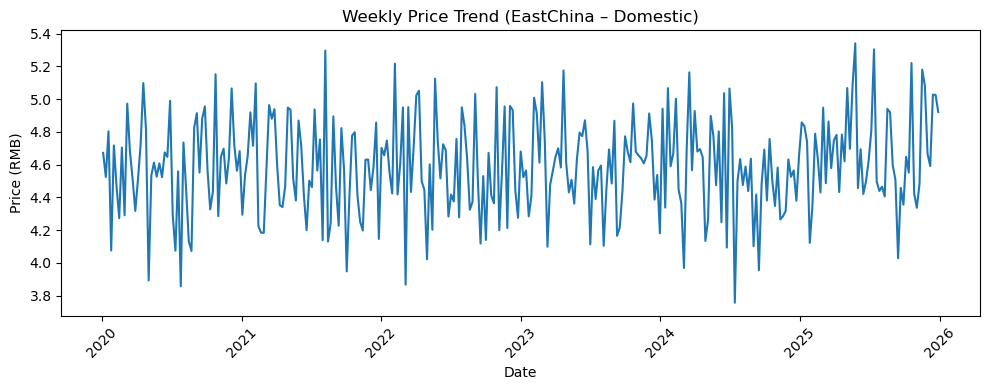

In [5]:
# 选择某地区、某商品类型，如 EastChina + Domestic
df_region_type = df[(df["region"] == "EastChina") & (df["type"] == "Domestic")]

# 按日期排序
df_sorted = df_region_type.sort_values("date")

# 价格趋势图
plt.figure(figsize=(10, 4))
plt.plot(df_sorted["date"], df_sorted["price"])
plt.xlabel("Date")
plt.ylabel("Price (RMB)")
plt.title("Weekly Price Trend (EastChina – Domestic)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [6]:
# 解析日期
df['date'] = pd.to_datetime(df['date'])

# 提取年份
df['year'] = df['date'].dt.year

# 将年份映射为 2024→0, 2025→1
df['year_index'] = df['year'] - df['year'].min()

# 按时间排序
df = df.sort_values(by='date')

# 提取月份
df['month'] = df['date'].dt.month

# 定义旺季（6–8 月）
peak_months = [6, 7, 8]
df['peak'] = df['month'].isin(peak_months).astype(int)

# # 可选：缩放销量（如果你后续优化模型数值较大时可以使用）
df['units_sold'] = df['units_sold'] / 1000000

# 如果只分析某种商品类型，例如 Domestic：
# df = df[df['type'] == 'Domestic']

# 保留所需字段
df = df[['date','units_sold','price','region','year','month','year_index','peak','type']].reset_index(drop=True)

df.head()


,date,units_sold,price,region,year,month,year_index,peak,type
0,2020-01-05,0.275230,4.6714,EastChina,2020,1,0,0,Domestic
1,2020-01-05,0.247515,5.7051,EastChina,2020,1,0,0,Imported
2,2020-01-05,0.225565,3.8147,NorthChina,2020,1,0,0,Domestic
3,2020-01-05,0.153486,5.3384,NorthChina,2020,1,0,0,Imported
4,2020-01-05,0.291166,4.5750,SouthChina,2020,1,0,0,Domestic


# 第一部分：描述性分析

接下来，我们将分析销售数据在时间维度上的变化，以及是否存在明显的季节性特征。  
为了使分析更直观，我们首先选取 **全国整体数据**（即所有地区的汇总趋势）进行初步探索。

通过观察整体层面的价格与销量走势，我们可以了解该生鲜商品在不同月份、不同年份之间的变化情况，并为后续的需求预测模型提供依据。


In [8]:
# 计算全国整体的平均价格和总销量（按日期聚合）
df_total = df.groupby('date', as_index=False).agg({
    'price': 'mean',
    'units_sold': 'sum'
})

In [9]:
df_total.head()

,date,price,units_sold
0,2020-01-05,4.99426,2.274934
1,2020-01-12,5.02384,2.340526
2,2020-01-19,4.90697,2.592851
3,2020-01-26,4.87338,2.486262
4,2020-02-02,4.83422,2.314955


## 月度的销量变化

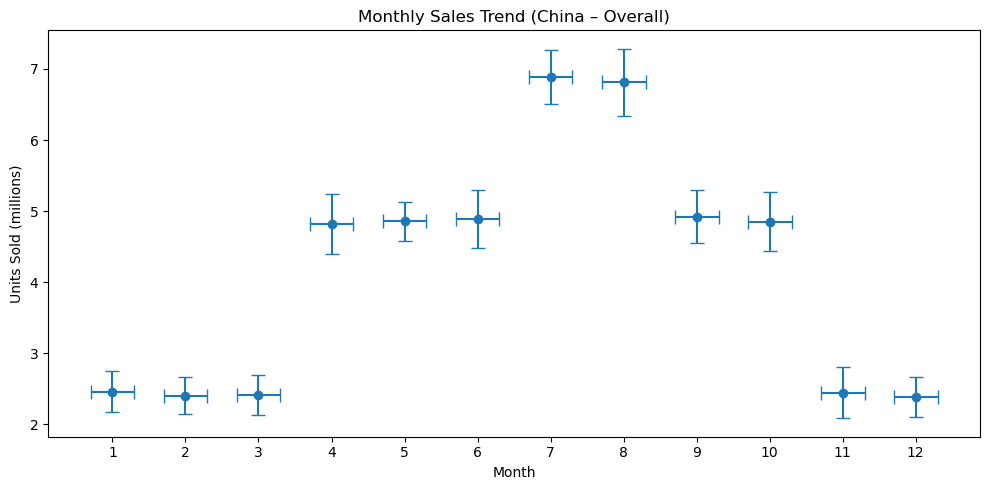

In [11]:
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(10, 5))

# 添加月份列
df_total['month'] = pd.to_datetime(df_total['date']).dt.month

# 按月份统计全国销量均值与标准差
mean = df_total.groupby('month')['units_sold'].mean()
std  = df_total.groupby('month')['units_sold'].std()

# 绘制误差棒图（均值 ± 2×标准差）
axes.errorbar(mean.index, mean, xerr=0.3, yerr=2*std, fmt='o', capsize=5)

axes.set_ylabel('Units Sold (millions)')
axes.set_xlabel('Month')
axes.set_title('Monthly Sales Trend (China – Overall)')

axes.set_xticks(range(1, 13))  # 显示 1~12 月

fig.tight_layout()
plt.show()


可以看到，多年来生鲜商品的销量总体呈上升趋势，虽然增长幅度并不大。

而 2019 年出现的销量下跌，则与当时广为报道的 2019 年生鲜商品供应短缺 有关 —— 该事件导致生鲜商品的价格 几乎翻倍上涨。

## 季节性分析（Seasonality）

接下来，我们继续观察销量在一年内部的变化趋势，也就是销售的季节性特征；按月份进行分析能够更清晰地展示消费高峰、淡季以及可能的周期性模式。


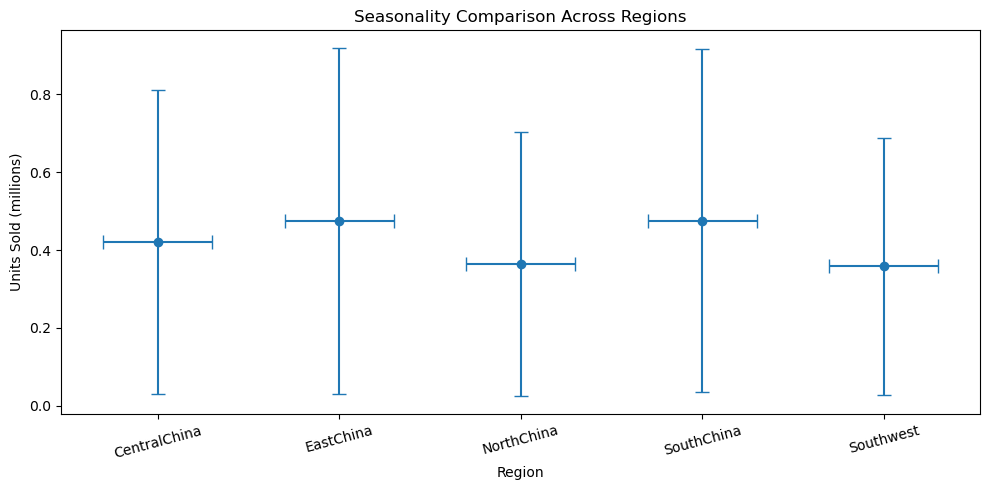

In [14]:
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(10, 5))

regions = ["EastChina", "NorthChina", "SouthChina", "Southwest", "CentralChina"]

# 确保有 month 列
df['month'] = pd.to_datetime(df['date']).dt.month

# 对每个地区：计算所有月份的销量均值（季节性平均）与标准差
mean = df.groupby('region')['units_sold'].mean()
std  = df.groupby('region')['units_sold'].std()

# 绘制误差棒图
axes.errorbar(
    range(len(mean)), 
    mean, 
    xerr=0.3, 
    yerr=2*std, 
    fmt='o', 
    capsize=5
)

plt.xlabel("Region")
plt.ylabel("Units Sold (millions)")
plt.title("Seasonality Comparison Across Regions")

# 设置横轴标签
plt.xticks(
    range(len(mean)), 
    mean.index, 
    rotation=15
)

plt.tight_layout()
plt.show()


# 第二部分：预测性分析

现在我们使用上一节构建的特征，对销售量进行回归建模。  
为了检验模型的泛化能力，我们将完整数据集随机划分为 **80% 的训练集** 和 **20% 的测试集**。

本例采用最常见的普通最小二乘回归（OLS）。模型中包含：

- $\text{price}_r$：地区 $r$ 的商品价格  
- $\text{year\_index}$：年份的顺序编码，用于捕捉整体年度趋势  
- $\text{c}_\text{region}$：不同地区对应的分类变量  
- $\text{peak}$：旺季指示变量（例如 6–8 月为 1，其余为 0）

拟合好的模型能够为任意一组给定的（价格、地区、年份、季节）预测对应的销售量（预测需求）。线性回归可写成：

$$
d(\text{price}_r,\, r) = \beta_0 
+ \beta_1 \cdot \text{price}_r
+ \sum_{r\in\text{R}} \beta_2^{r} \cdot \mathbf{1}_{\text{region}}
+ \beta_3 \cdot \text{year\_index}
+ \beta_4 \cdot \mathbf{1}_{\text{peak}}
$$

其中：

- $\beta$ 为模型需要学习的回归系数；  
- $\mathbf{1}_{\text{region}}$：为地区的指示变量，每个地区对应一个 0/1 的标记；  
- $\text{year\_index}$ 为年份的顺序编码（例如 2020→0，2021→1，以此类推）；  
- $\mathbf{1}_{\text{peak}}$：表示是否处于旺季（例如 6–8 月），旺季为 1，否则为 0。否则为 0。

为了评估模型效果，我们将数据随机划分为 **80% 的训练集** 和 **20% 的测试集**，并使用 sklearn 的线性回归工具来拟合这些参数。

代码实现如下步骤：
1. 数据集拆分  
2. 使用训练集进行模型拟合  
3. 输出回归系数摘要  
4. 在测试集上计算 R² 指标，用于评估模型对未见数据的预测效果

In [16]:
import statsmodels.formula.api as smf
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

# 1. 划分训练集和测试集
df_train, df_test = train_test_split(df, train_size=0.8, random_state=1)

# 2. 构建 OLS 回归模型
formula = 'units_sold ~ price + year_index + C(region) + peak'
model = smf.ols(formula=formula, data=df_train)
result = model.fit()

# 3. 输出回归结果
print(result.summary())

# 4. 测试集 R²
y_true = df_test['units_sold']
y_pred = result.predict(df_test)
print("Test R²:", r2_score(y_true, y_pred))


                            OLS Regression Results                            
Dep. Variable:             units_sold   R-squared:                       0.585
Model:                            OLS   Adj. R-squared:                  0.584
Method:                 Least Squares   F-statistic:                     502.6
Date:                Wed, 24 Jun 2026   Prob (F-statistic):               0.00
Time:                        16:56:12   Log-Likelihood:                 1533.8
No. Observations:                2504   AIC:                            -3052.
Df Residuals:                    2496   BIC:                            -3005.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                 

In [17]:
import statsmodels.formula.api as smf
from sklearn.metrics import r2_score

# 使用 EastChina 作为 baseline
formula = 'units_sold ~ price + year_index + C(region, Treatment(reference="EastChina")) + peak'

mod_full = smf.ols(formula=formula, data=df)
result_full = mod_full.fit()

y_true_full = df['units_sold']
y_pred_full = result_full.predict(df)

print("The R^2 value in the full dataset is", r2_score(y_true_full, y_pred_full))

coef_dict = result_full.params.to_dict()
coef_dict

The R^2 value in the full dataset is 0.5821639691660185


{'Intercept': 1.2260585668685309,
 'C(region, Treatment(reference="EastChina"))[T.CentralChina]': -0.07132362930407651,
 'C(region, Treatment(reference="EastChina"))[T.NorthChina]': -0.1419842932835118,
 'C(region, Treatment(reference="EastChina"))[T.SouthChina]': 0.0007454305157608004,
 'C(region, Treatment(reference="EastChina"))[T.Southwest]': -0.14621482800069435,
 'price': -0.162331102379062,
 'year_index': -0.0009270836776584209,
 'peak': 0.26955485004449303}

$$
d(\text{price}_r,\, r) = \beta_0 
+ \beta_1 \cdot \text{price}_r
+ \sum_{r\in\text{R}} \beta_2^{r} \cdot \mathbf{1}_{\text{region}}
+ \beta_3 \cdot \text{year\_index}
+ \beta_4 \cdot \mathbf{1}_{\text{peak}}
$$

上式中，除决策变量 $\text{price}_r$ 外，其余系数均已通过 OLS 拟合求解确定，在后续优化模型求解过程中可作为常数代入计算。

# 第三部分：决策性分析

此前的预测部分已经构建了一个能够预测销量的回归模型，可以根据价格、地区、年份和季节性等因素估计未来的需求。接下来，本案例将结合预测模型与数学优化模型，调用COPT求解器，求解在有限库存条件下，怎样定价和分配商品才能获得最大收益的问题。通过该部分，即可实现完整的**从数据到决策**的过程。

在实际的生鲜零售场景中，商家通常会面临如下问题：

- **价格定高了**：单个利润高，但销量下降；
- **价格定低了**：销量上升，但收入未必最大；
- **供应量有限**：如何在多个地区之间分配？  
- **运输和浪费成本**不可忽视；
- **旺季与淡季**对不同地区的影响不同。


## 导入COPT-Python接口库

In [24]:
import coptpy as cp
from coptpy import COPT

## 创建求解环境和求解模型

In [30]:
env = cp.Envr()
m = env.createModel("Fresh_Product_Price_Allocation")

Cardinal Optimizer v8.0.5. Build date May 30 2026
Copyright Cardinal Operations 2026. All Rights Reserved



In [31]:
# 集合与参数
R = regions   # 所有区域的集合，例如 ["EastChina", "NorthChina", ...]
Cap = 5.0       # 总供应量（单位：百万件生鲜商品）

peak_or_not = 1      # 1 表示旺季，0 表示淡季
year = 2023          

# 浪费成本（单位：元/件，对应到模型中即 元/百万件 的量纲缩放）
c_waste = 0.2

# 各区域运输成本（单位：元/件）
c_transport = {
    "EastChina":   0.08,
    "NorthChina":  0.10,
    "SouthChina":  0.06,
    "CentralChina":0.09,
    "Southwest":   0.12,
}

# 从数据中获取价格和供给数量的上下界
# 价格上下界：例如限制在 [3, 10] 元之间
price_min = {r: 3.0 for r in R}   # 区域 r 的最小价格
price_max = {r: 10.0 for r in R}  # 区域 r 的最大价格

# 供给量上下界：用历史销量（已按百万缩放）作为“合理区间”
supply_min = dict(df.groupby("region")["units_sold"].min())  # 每个区域最小供给量（百万件）
supply_max = dict(df.groupby("region")["units_sold"].max())  # 每个区域最大供给量（百万件）


## 添加模型三要素

### 添加决策变量
 
在本模型中，我们希望对每个地区的定价以及分配数量进行决策，同时还需要显式刻画“预计卖出多少”和“预计浪费多少”。  
对每个地区 $r \in \text{R}$ ，记：

- $\text{price}_r$ ：地区 $r$ 的生鲜商品单价（元）；
- $\text{num}_r$ ：分配给地区 $r$ 的生鲜商品数量（与前文单位保持一致，例如“百万件”）；
- $\text{supply}_r = \min \{\text{num}_r,\; d(\text{price}_r,\, r)\}$ ：地区 $r$ 预测能够售出的生鲜商品数量；
- $\text{waste}_r = \text{num}_r - \text{supply}_r$ ：地区 $r$ 预测被浪费的生鲜商品数量。


In [35]:
# excess wasteage in each region
price = m.addVars(R,lb=price_min, ub=price_max, nameprefix="p")   
num = m.addVars(R,lb=supply_min, ub=supply_max, nameprefix="x")  
supply = m.addVars(R,lb=0, nameprefix="s")   
waste = m.addVars(R,lb=0, nameprefix="w")   

$$
d(\text{price}_r,\, r) = \beta_0 
+ \beta_1 \cdot \text{price}_r
+ \sum_{r\in\text{R}} \beta_2^{r} \cdot \mathbf{1}_{\text{region}}
+ \beta_3 \cdot \text{year\_index}
+ \beta_4 \cdot \mathbf{1}_{\text{peak}}
$$

需求预测函数中，除了价格之外，其他参数（例如地区、年份和季节性）都不是决策变量，因此可以视为常数处理。

In [38]:
d = {}

for r in R:
    # 从截距开始
    expr = coef_dict["Intercept"]

    # 价格项：beta_price * p_r
    expr += coef_dict["price"] * price[r]

    # 地区 dummy 项：如果 key 不存在，说明是基准地区，系数为 0
    region_key = f"C(region)[T.{r}]"
    if region_key in coef_dict:
        expr += coef_dict[region_key]
    # 否则是 baseline，不需要加

    # 年份项：year_index = year - 2020（数据是 2020–2025）
    expr += coef_dict["year_index"] * (year - 2020)

    # 旺季项
    expr += coef_dict["peak"] * peak_or_not

    d[r] = expr

### 设定目标函数

接下来，我们来定义目标函数：希望 **最大化所有地区的总净收入（net revenue）**。

每个地区的销售收入由 “该地区的生鲜商品单价” 与 “该地区售出的数量” 相乘得到。  
在成本方面，考虑两类成本：

1. 未售出、被浪费的生鲜商品产生的浪费成本；
2. 将生鲜商品运输到各个地区所产生的运输成本；
3. 其余成本假设均为固定成本，不纳入目标函数考虑。

**净收入构成**：销售收入 - 商品浪费成本 - 运输成本

净收益计算公式如下：

$$
    \max \; \sum_{r \in \text{R}} \Big(\text{price}_r \, \text{supply}_r - \text{c}_{\text{waste}} \, \text{waste}_r - \text{c}^{r}_{\text{transport}} \, \text{num}_r \Big)
$$


In [42]:
m.setObjective(cp.quicksum(price[r]*supply[r] - c_waste*waste[r] - c_transport[r]*num[r] for r in R), sense=COPT.MAXIMIZE) 

### 添加约束条件
1. **供应量约束**：该约束用于确保分配到各地区的生鲜商品总量必须等于给定的总供应量 $Cap$。
$$
    \sum_{r \in \text{R}} \text{num}_r = \text{Cap}
$$

In [49]:
m.addConstr(cp.quicksum(num[r] for r in R) == Cap)

<coptpy.Constraint: >

2. **销售数量约束**:：添加约束刻画各地区的预测销售数量。

- 如果供应量大于预测需求量，则实际销售量等于预测需求量；  
- 如果供应量小于或等于预测需求量，则实际销售量等于供应量。  

因此，地区 $r$ 的预测销售量可以表示为两者的较小值：

$$
    \text{supply}_r \leq \min \{\text{num}_r,\, d(\text{price}_r,\, r)\}, \quad \forall\, r\in \text{R}
$$

这一关系可以通过对每个地区 $r$ 添加以下两组不等式来表示：

$$
\begin{aligned}
    \text{supply}_r &\leq \text{num}_r, \\
    \text{supply}_r &\leq d(\text{price}_r,\, r), \quad \forall\, r\in \text{R}
\end{aligned}
$$


In [52]:
m.addConstrs((supply[r] <= num[r] for r in R))
m.addConstrs((supply[r] <= d[r] for r in R)) 


3. **浪费数量约束**：定义各地区的预测浪费量等于供应量中**未被售出**的部分。

$$
    \text{waste}_r = \text{num}_r - \text{supply}_r, \quad \forall\, r\in \text{R}
$$


In [55]:
m.addConstrs((waste[r] == num[r]-supply[r] for r in R))

## 求解

本模型目标函数包含价格与销量相乘的二次交叉项，构成**非凸二次规划问题**（Nonconvex QP），COPT 可默认求解非凸二次规划问题，也可通过设置优化参数 `NonConvex`求得非凸问题的全局最优解。

In [74]:
m.setParam("NonConvex", 2) 
m.solve()

Model fingerprint: 82b040d3

Using Cardinal Optimizer v8.0.5 on Windows (22H2 Build 19045 - x86_64)
The CPU model is Intel(R) Core(TM) i5-10210U CPU @ 1.60GHz
Hardware has 4 physical cores and 8 logical cores. Using instruction set X86_AVX2 (10)
Maximizing a QP problem

The original problem has:
    16 rows, 20 columns and 40 non-zero elements
    5 quadratic objective elements

The problem is identified as a non-convex QP, finding global optimum
Starting the MIP solver with 8 threads and 32 tasks

Presolving the problem

The presolved problem has:
    27 rows, 16 columns and 81 non-zero elements
    1 quadratic rows

Problem info:
    Range of matrix coefficients:    [0e+00,9e+00]
    Range of rhs coefficients:       [1e+00,1e+01]
    Range of bound coefficients:     [1e+00,7e+01]
    Range of cost coefficients:      [1e-01,1e+00]
    Density of cost:                     37.5%

     Nodes    Active  LPit/n  IntInf     BestBound  BestSolution     Gap   Time
         0         1      --

## 获取模型求解结果

In [76]:
import pandas as pd

solution = pd.DataFrame()
solution["Region"] = R
solution["Price"] = [price[r].X for r in R]
solution["Allocated"] = [round(num[r].X, 8) for r in R]   # 分配量（百万件）
solution["Sold"] = [round(supply[r].X, 8) for r in R]        # 销量（百万件）
solution["Wasted"] = [round(waste[r].X, 8) for r in R]      # 浪费量（百万件）

# 按回归模型公式，计算每个地区在最优价格下的预测需求（百万件）
pred_demand = []
for r in R:
    # 地区 dummy 项：如果是基准地区，coef_dict 中没有该键，默认 0
    region_key = f"C(region)[T.{r}]"
    beta_region = coef_dict.get(region_key, 0.0)
    
    val = (
        coef_dict["Intercept"]
        + coef_dict["price"] * solution.loc[solution["Region"] == r, "Price"].iloc[0]
        + beta_region
        + coef_dict["year_index"] * (year - 2020)   
        + coef_dict["peak"] * peak_or_not
    )
    pred_demand.append(val)

solution["Pred_demand"] = [round(v, 8) for v in pred_demand]  # 预测需求（百万件）

# 最优净收益
opt_revenue = m.bestobj
print(f"\nThe optimal net revenue: {opt_revenue:.4f} (model unit: million RMB)")

solution


The optimal net revenue: 16.5009 (model unit: million RMB)


,Region,Price,Allocated,Sold,Wasted,Pred_demand
0,EastChina,4.508109,0.761026,0.761026,-0.000000,0.761026
1,NorthChina,4.518109,0.759403,0.759403,0.000000,0.759403
2,SouthChina,4.498109,1.961578,0.762649,1.198929,0.762649
3,Southwest,4.528109,0.757779,0.757779,0.000000,0.757779
4,CentralChina,4.513109,0.760214,0.760214,0.000000,0.760214


## 结果分析

In [99]:
# 初始化列表
region_revenue_list = []    # 地区销售收入
region_trans_cost_list = [] # 地区总运输成本
region_waste_cost_list = [] # 地区滞销浪费总成本
region_profit_list = []     # 地区净利润

for idx, r in enumerate(solution["Region"]):
    p = solution.loc[idx, "Price"]
    sold = solution.loc[idx, "Sold"]
    allocated = solution.loc[idx, "Allocated"]
    wasted = solution.loc[idx, "Wasted"]
    
    # 1. 销售收入 = 售价 × 实际卖出数量
    revenue = p * sold
    # 2. 运输总成本 = 单位运费 × 调拨总供货量
    trans_cost = c_transport[r] * allocated
    # 3. 商品浪费成本 = 单位损耗成本 × 报废数量
    waste_cost = c_waste * wasted
    # 4. 单地区净利润 = 营收 - 运输成本 - 损耗成本
    net_profit = revenue - trans_cost - waste_cost
    
    region_revenue_list.append(round(revenue, 8))
    region_trans_cost_list.append(round(trans_cost, 8))
    region_waste_cost_list.append(round(waste_cost, 8))
    region_profit_list.append(round(net_profit, 8))

# 新增四列盈利指标
solution["Sales_Revenue"] = region_revenue_list
solution["Transport_Cost"] = region_trans_cost_list
solution["Waste_Cost"] = region_waste_cost_list
solution["Region_Net_Profit"] = region_profit_list

# 全局汇总统计
total_revenue = solution["Sales_Revenue"].sum()
total_trans_cost = solution["Transport_Cost"].sum()
total_waste_cost = solution["Waste_Cost"].sum()
total_net_profit = solution["Region_Net_Profit"].sum()
total_allocated = solution["Allocated"].sum()
total_waste_qty = solution["Wasted"].sum()
waste_rate = total_waste_qty / total_allocated if total_allocated != 0 else 0

# 打印输出明细
print("=" * 80)
print("各地区运营明细汇总表（单位：数量=百万件，金额=百万元）")
print("=" * 80)
print(solution.set_index("Region").round(4))

print("\n" + "=" * 80)
print("全局整体经营汇总结果")
print("=" * 80)
print(f"总销售收入：{total_revenue:.4f} 百万元")
print(f"总运输成本：{total_trans_cost:.4f} 百万元")
print(f"总商品浪费成本：{total_waste_cost:.4f} 百万元")
print(f"模型全局最优总净利润：{total_net_profit:.4f} 百万元")
print(f"全局总调拨供货量：{total_allocated:.4f} 百万件")
print(f"全局总滞销报废量：{total_waste_qty:.4f} 百万件")
print(f"整体商品损耗率：{waste_rate:.2%}")
print("=" * 80)


各地区运营明细汇总表（单位：数量=百万件，金额=百万元）
               Price  Allocated    Sold  Wasted  Pred_demand  Sales_Revenue  \
Region                                                                        
EastChina     4.5081     0.7610  0.7610 -0.0000       0.7610         3.4308   
NorthChina    4.5181     0.7594  0.7594  0.0000       0.7594         3.4311   
SouthChina    4.4981     1.9616  0.7626  1.1989       0.7626         3.4305   
Southwest     4.5281     0.7578  0.7578  0.0000       0.7578         3.4313   
CentralChina  4.5131     0.7602  0.7602  0.0000       0.7602         3.4309   

              Transport_Cost  Waste_Cost  Region_Net_Profit  
Region                                                       
EastChina             0.0609     -0.0000             3.3699  
NorthChina            0.0759      0.0000             3.3551  
SouthChina            0.1177      0.2398             3.0730  
Southwest             0.0909      0.0000             3.3404  
CentralChina          0.0684      0.0000     

### 结果分析
本次优化模型全局总净利润为 16.5009 百万元，整体商品损耗率 23.98%，亏损损耗全部来自华南区域。
1. 华东、华北、西南、华中四区：供货量与实际销量完全相等，无滞销浪费，定价匹配市场需求，盈利稳定；
2. 华南地区：投放货品过多，出现大量滞销报废，利润明显低于其他区域，是整体利润短板；
3. 各区域定价区间接近，实际销量与模型预测需求量基本吻合，需求回归模型有效。
### 决策建议
1. 定价：华南地区商品需求对价格更敏感，建议适当下调该区域售价以拉动销量；华东、华北、华中、西南四地当前定价盈利表现较好，保持现有最优价格不变即可；
2. 货品调配：适当减少分配给华南的货品量，将富余货源调配至其余盈利更稳定的区域，减少商品浪费；
3. 长期运营方案：依托需求预测模型按需分配货品，重点控制华南库存积压问题，通过精细化定价与配货模式，减少损耗、提升整体利润。